In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [7]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [8]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_151617_thirty.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/thirty


Launched SVR

In [9]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [10]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [11]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 45.95065702027774
R2 -> 0.7807859710403531
MAPE -> 0.051349246921758566


{'d2_absolute_error_score': 0.5566412602864119,
 'd2_pinball_score': 0.5566412602864119,
 'd2_tweedie_score': 0.7807859710403531,
 'explained_variance_score': 0.7834360158651736,
 'max_error': 219.13862634179338,
 'mean_absolute_error': 30.936467156465334,
 'mean_absolute_percentage_error': 0.051349246921758566,
 'mean_gamma_deviance': 0.00572481822136867,
 'mean_poisson_deviance': 3.4375682922324535,
 'mean_squared_error': 2111.4628805951997,
 'mean_squared_log_error': 0.00581050835689348,
 'median_absolute_error': 19.683101278528056,
 'r2_score': 0.7807859710403531,
 'root_mean_squared_error': 45.95065702027774,
 'root_mean_squared_log_error': 0.07622669058075052}

Plots:

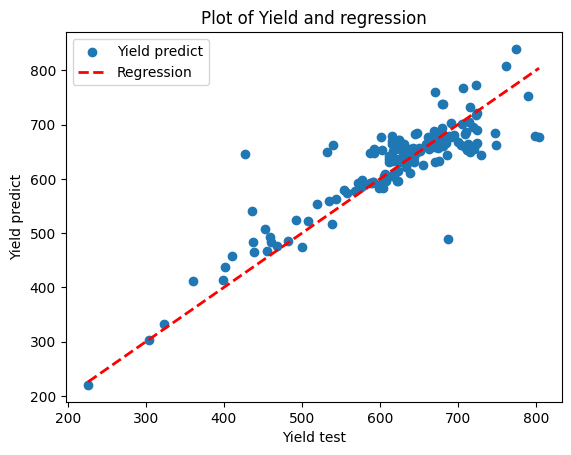

In [12]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [13]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [14]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 427.0, 'predict': 646.1386263417934, 'error': 0.513205213915207},
 {'truth': 687.2559,
  'predict': 489.18956334840686,
  'error': 0.28819881597465097},
 {'truth': 436.0, 'predict': 540.5289905867529, 'error': 0.23974539125402045},
 {'truth': 540.0, 'predict': 662.5542593199457, 'error': 0.2269523320739735},
 {'truth': 532.0, 'predict': 649.986442851528, 'error': 0.22177902791640594},
 {'truth': 804.0, 'predict': 676.5952645567107, 'error': 0.15846360129762346},
 {'truth': 799.0, 'predict': 678.6628723961526, 'error': 0.15060967159430216},
 {'truth': 360.0, 'predict': 411.58768657443994, 'error': 0.14329912937344427},
 {'truth': 670.0, 'predict': 760.246296744963, 'error': 0.13469596529098962},
 {'truth': 601.0, 'predict': 677.4900227238379, 'error': 0.12727125245230933},
 {'truth': 453.0, 'predict': 507.52653832020013, 'error': 0.12036763426092745},
 {'truth': 409.865,
  'predict': 458.29417595104843,
  'error': 0.11815884730593834},
 {'truth': 749.0, 'predict': 661.7590492